In [2]:
import cv2
import numpy as np
from datasets import load_dataset
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [3]:
dataset = load_dataset("HZhang729/Nike_Shoes_Classification", split='train[:500]')

README.md:   0%|          | 0.00/263 [00:00<?, ?B/s]

c:\Users\jjsd4\workspace\torch\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\jjsd4\.cache\huggingface\hub\datasets--HZhang729--Nike_Shoes_Classification. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


archive%20%282%29.zip:   0%|          | 0.00/24.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1216 [00:00<?, ? examples/s]

## <font color=yellow>1. SIFT</font>
- 128차원의 descriptors 벡터를 추출함
- 이미지를 PIL 형식에서 Numpy로 변환함
- RGB를 Gray로 변환 (흑백)
    - 실제 알고리즘에서는 RGB를 고려하지 않고 흑백이미지로 descriptor를 뽑아서 이렇게 해야함

- 특정한 feature를 감지하지 못하면 else:문에서 처리함 
    - (0, ...): 0으로 채워진 128차원 벡터

- 이후 sparse 한 vector로 변환
    - descriptors의 차원이 각기 다 다름
    - SIFT로 인해 추출되는 feature 갯수가 전부 다른듯
    - 그래서 feature 추출 갯수만큼 histogram의 분포모양이 나오는 듯

In [4]:
def extract_sift_features(image):
    sift = cv2.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(image, None)
    return descriptors

In [5]:
image_descriptors = []

for imageset in dataset:
    image = np.array(imageset['image'])
    gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    descriptors = extract_sift_features(gray_image)

    if descriptors is not None:
        descriptors = descriptors.astype(np.float32)
        image_descriptors.append(descriptors)
    else:
        image_descriptors.append(np.zeros((1, 128), dtype=np.float32))

# KMeans 클러스터링을 위한 SIFT 벡터 Vertical Stack
all_descriptors = np.vstack([desc for desc in image_descriptors if desc is not None])

num_clusters = 10
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(all_descriptors)

def image_to_histogram(image_desc):
    labels = kmeans.predict(image_desc)
    hist, _ = np.histogram(labels, bins=np.arange(num_clusters+1), density=True)
    return hist

image_histograms = [image_to_histogram(desc) for desc in image_descriptors]

In [6]:
descriptors

array([[  1.,  42., 160., ...,   0.,   2.,   0.],
       [  0.,   0.,   0., ...,   3.,   2.,   1.],
       [  1.,   4.,   2., ...,   1.,   0.,   0.],
       ...,
       [ 51.,  21.,   0., ...,   0.,   0.,   1.],
       [ 32.,  22.,   1., ...,   1.,   1.,   2.],
       [ 22.,   7.,   0., ...,   0.,   0.,   0.]], dtype=float32)

In [7]:
descriptors.shape

(267, 128)

In [9]:
len(image_descriptors)

500

In [10]:
image_descriptors[0].shape

(254, 128)

In [11]:
image_descriptors[1].shape

(998, 128)

## <font color=green>quantized vector 결과:</font>
- clustering 갯수처럼 10가지로 나옴

In [12]:
image_histograms[50]

array([0.07712766, 0.06914894, 0.10638298, 0.11170213, 0.03989362,
       0.16755319, 0.14095745, 0.04787234, 0.05585106, 0.18351064])

In [13]:
image_histograms[2]

array([0.24698795, 0.04819277, 0.05421687, 0.05220884, 0.04216867,
       0.09036145, 0.33534137, 0.04016064, 0.02409639, 0.06626506])

## <font color=yellow>2. quantized 된 후, 되기 전의 descriptor 시각화를 해보겠음</font>

In [14]:
def extract_and_draw_keypoints_quantized(image, kmeans_model):
    gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    sift = cv2.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(gray_image, None)

    if descriptors is None:
        return image

    descriptors = descriptors.astype(np.float32)
    labels = kmeans_model.predict(descriptors)

    output_image = image.copy()
    for keypoint, label in zip(keypoints, labels):
        color = plt.cm.get_cmap('hsv', num_clusters)(label)
        color = tuple([int(x * 255) for x in color[:3]])
        x, y = keypoint.pt
        cv2.circle(output_image, (int(x), int(y)), 3, color, -1)

    return output_image

def extract_and_draw_keypoints(image):
    if not isinstance(image, np.ndarray):
        image = np.array(image)

    gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    sift = cv2.SIFT_create()
    keypoints, _ = sift.detectAndCompute(gray_image, None)
    keypoint_image = cv2.drawKeypoints(image, keypoints, None)
    return keypoint_image

### SIFT 알고리즘이 추출한 영역들

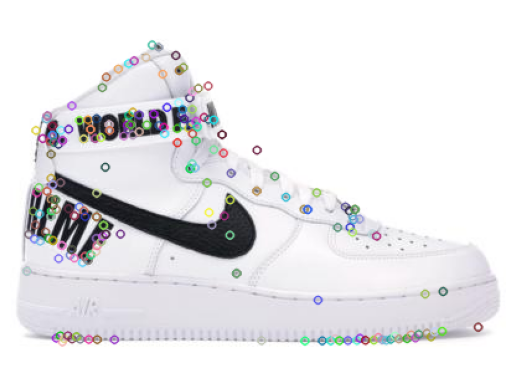

In [26]:
#생성된 SIFT VECTOR의 Keypoints 확인
query_img_with_keypoints = extract_and_draw_keypoints(dataset[0]['image'])

plt.imshow(query_img_with_keypoints)
plt.axis('off')
plt.show()

### 코드북에 실질적으로 나타난 영역들
- 색에 따라 동일한 특징을 볼 수 있음

C:\Users\jjsd4\AppData\Local\Temp\ipykernel_23072\2227425315.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color = plt.cm.get_cmap('hsv', num_clusters)(label)


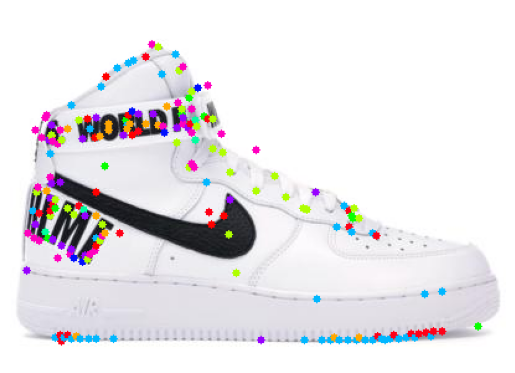

In [16]:
#생성된 SIFT VECTOR의 Quantized Keypoints 확인
colored_keypoints_image = extract_and_draw_keypoints_quantized(np.array(dataset[0]['image']), kmeans)
plt.imshow(colored_keypoints_image)
plt.axis('off')
plt.show()

## <font color=yellow>3. 유사도 검색</font>
- 유사한 이미지
- 유사하지 않은 이미지

In [27]:
def retrieve_images(query_idx, histograms, top_k=3):
    query_hist = histograms[query_idx]
    similarities = [cosine_similarity(query_hist.reshape(1, -1), hist.reshape(1, -1))[0][0] for hist in histograms]

    # 쿼링 이미지 제외 나머지 이미지들에 대해 일괄적으로 코사인 유사도 기준 소팅
    similarities = [(idx, sim) for idx, sim in enumerate(similarities) if idx != query_idx]
    similarities.sort(key=lambda x: x[1], reverse=True)

    # 가장 유사한 이미지와 안비슷한 이미지 추출
    similar_images = [idx for idx, _ in similarities[:top_k]]
    dissimilar_images = [idx for idx, _ in similarities[-top_k:]]

    return similar_images, dissimilar_images

## <font color=yellow>3-1. 65번 사진</font>

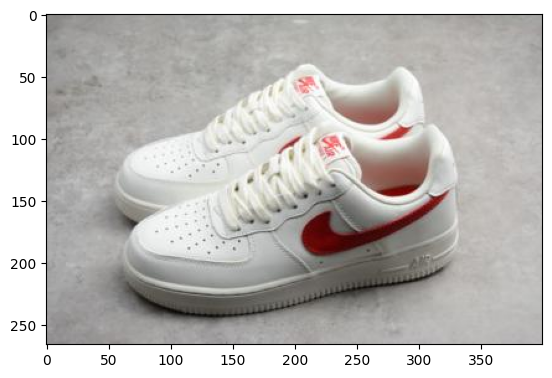

In [28]:
plt.imshow(dataset[65]['image'])

C:\Users\jjsd4\AppData\Local\Temp\ipykernel_23072\2227425315.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color = plt.cm.get_cmap('hsv', num_clusters)(label)


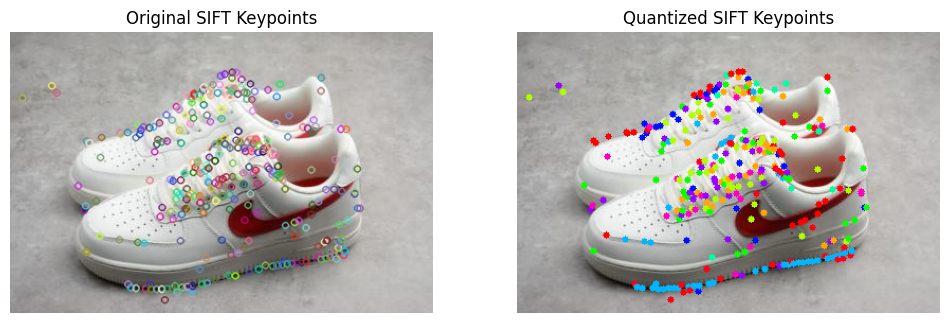

In [29]:
query_idx = 65
similar_images, dissimilar_images = retrieve_images(query_idx, image_histograms)
#생성된 SIFT VECTOR의 keypoints 확인
query_img_with_keypoints = extract_and_draw_keypoints(dataset[query_idx]['image'])
colored_keypoints_image = extract_and_draw_keypoints_quantized(np.array(dataset[query_idx]['image']), kmeans)
plt.figure(figsize=(12, 6))

# Original keypoints
plt.subplot(1, 2, 1)
plt.imshow(query_img_with_keypoints)
plt.title('Original SIFT Keypoints')
plt.axis('off')

# Quantized keypoints
plt.subplot(1, 2, 2)
plt.imshow(colored_keypoints_image)
plt.title('Quantized SIFT Keypoints')
plt.axis('off')

plt.show()

SIFT 알고리즘은 평이한 특징은 안잡고, 평이하지 않은 특징을 잡는데 주력하는 알고리즘임
- 모든 키포인트들이 깔끔하게 묶이지 않는 것을 사진에서 볼 수 있음
- centroid 포인트를 10개로 잡았는데, 이미지 내에서 특징 분류가 10개만큼 많지는 않다는 것을 알 수 있음
- 이렇게 이미지 키포인트들을 확인하고, centroid를 조절해주는게 좋을 듯
    - k값이 너무 크구나, 줄여봐야겠다는 뜻

이미지 질감이나 모양새적인 특성의 유사성을 나타내는데 특화된 모델이라는 것을 알 수 있음

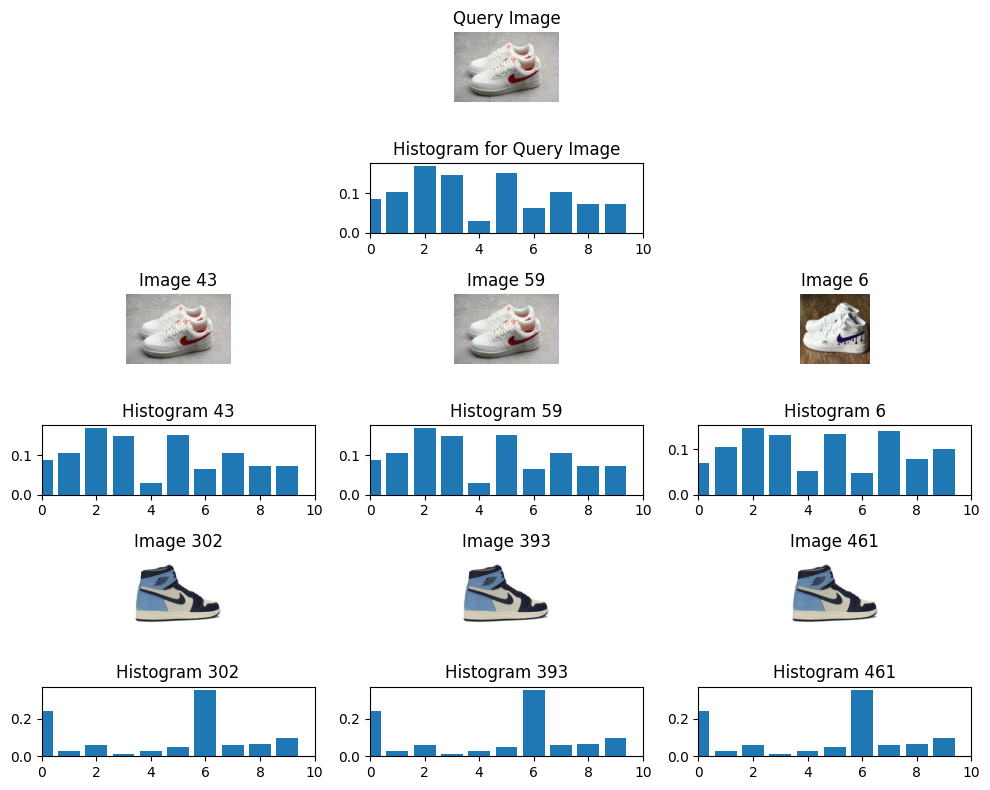

In [30]:
def display_row_of_images_and_histograms(image_indices, row, gs, num_bins):
    for i, idx in enumerate(image_indices):
        ax_img = plt.subplot(gs[row, i])
        ax_img.imshow(dataset[idx]['image'])
        ax_img.set_title(f'Image {idx}')
        ax_img.axis('off')

        ax_hist = plt.subplot(gs[row + 1, i])
        ax_hist.bar(range(num_bins), image_histograms[idx])
        ax_hist.set_title(f'Histogram {idx}')
        ax_hist.set_xlim([0, num_bins])

plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(6, 3)

plt.subplot(gs[0, :])
plt.imshow(dataset[query_idx]['image'])
plt.title('Query Image')
plt.axis('off')

plt.subplot(gs[1, 1])
plt.bar(range(num_clusters), image_histograms[query_idx])
plt.title('Histogram for Query Image')
plt.xlim([0, num_clusters])

display_row_of_images_and_histograms(similar_images, 2, gs, num_clusters)

display_row_of_images_and_histograms(dissimilar_images, 4, gs, num_clusters)

plt.tight_layout()
plt.show()

## <font color=yellow>3-1. 456번 사진</font>

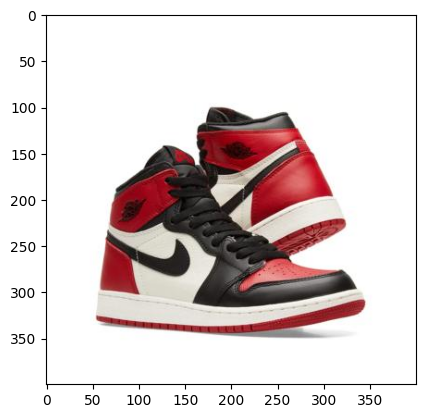

In [37]:
plt.imshow(dataset[456]['image'])

C:\Users\jjsd4\AppData\Local\Temp\ipykernel_23072\2227425315.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color = plt.cm.get_cmap('hsv', num_clusters)(label)


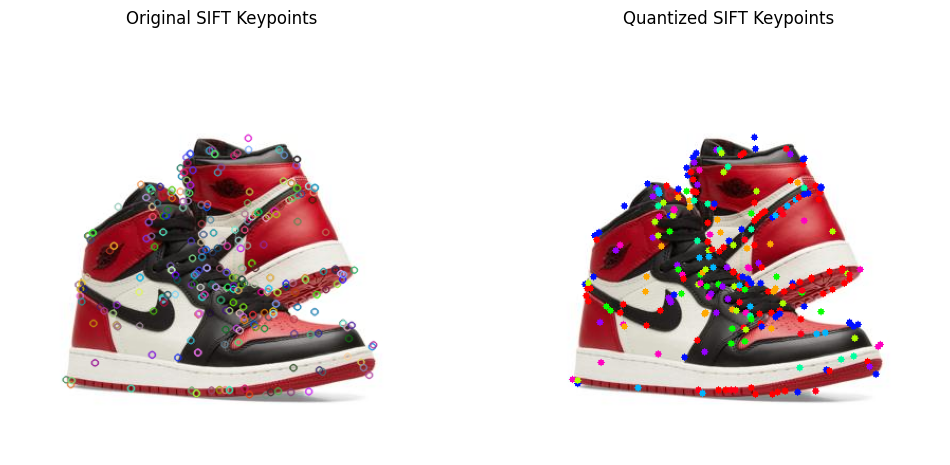

In [38]:
query_idx = 456
similar_images, dissimilar_images = retrieve_images(query_idx, image_histograms)
#생성된 SIFT VECTOR의 keypoints 확인
query_img_with_keypoints = extract_and_draw_keypoints(dataset[query_idx]['image'])
colored_keypoints_image = extract_and_draw_keypoints_quantized(np.array(dataset[query_idx]['image']), kmeans)
plt.figure(figsize=(12, 6))

# Original keypoints
plt.subplot(1, 2, 1)

plt.imshow(query_img_with_keypoints)
plt.title('Original SIFT Keypoints')
plt.axis('off')

# Quantized keypoints
plt.subplot(1, 2, 2)

plt.imshow(colored_keypoints_image)
plt.title('Quantized SIFT Keypoints')
plt.axis('off')

plt.show()

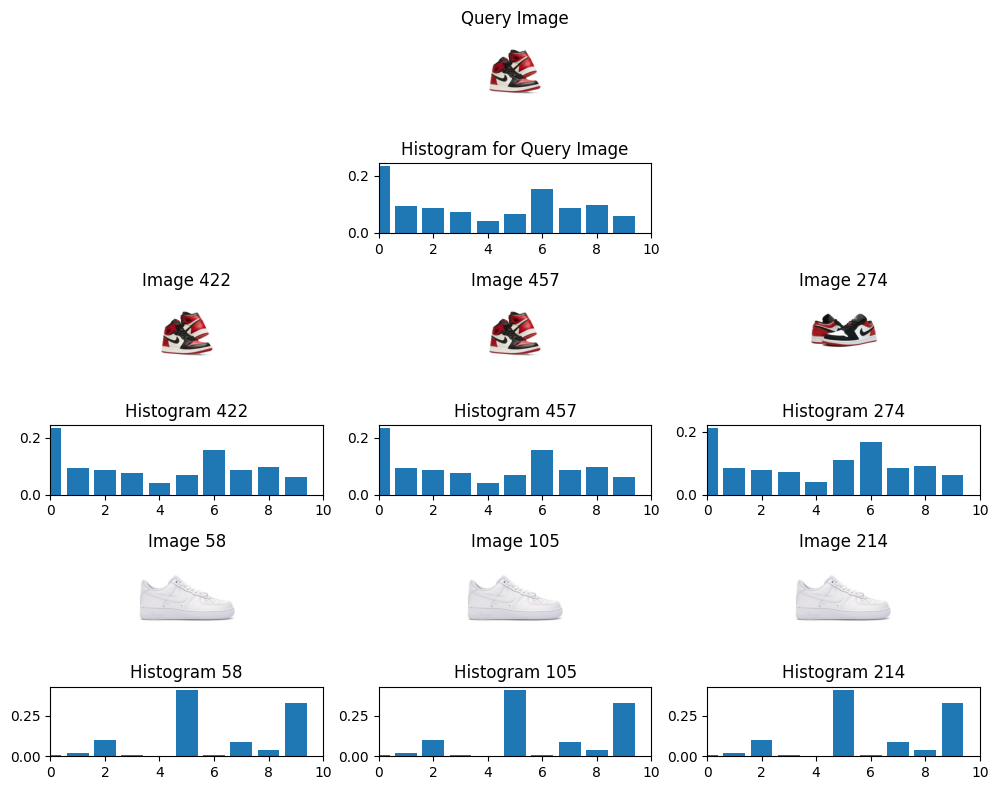

In [ ]:
def display_row_of_images_and_histograms(image_indices, row, gs, num_bins):
    for i, idx in enumerate(image_indices):
        ax_img = plt.subplot(gs[row, i])
        ax_img.imshow(dataset[idx]['image'])
        ax_img.set_title(f'Image {idx}')
        ax_img.axis('off')

        ax_hist = plt.subplot(gs[row + 1, i])
        ax_hist.bar(range(num_bins), image_histograms[idx])
        ax_hist.set_title(f'Histogram {idx}')
        ax_hist.set_xlim([0, num_bins])

plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(6, 3)

plt.subplot(gs[0, :])
plt.imshow(dataset[query_idx]['image'])
plt.title('Query Image')
plt.axis('off')

plt.subplot(gs[1, 1])
plt.bar(range(num_clusters), image_histograms[query_idx])
plt.title('Histogram for Query Image')
plt.xlim([0, num_clusters])

display_row_of_images_and_histograms(similar_images, 2, gs, num_clusters)

display_row_of_images_and_histograms(dissimilar_images, 4, gs, num_clusters)

plt.tight_layout()
plt.show()

## <font color=yellow>3-1. 155번 사진</font>

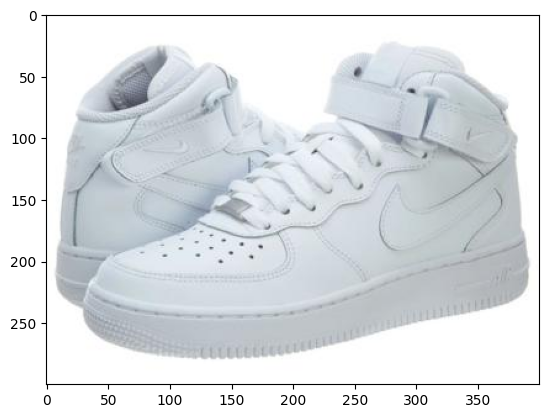

In [40]:
plt.imshow(dataset[155]['image'])

C:\Users\jjsd4\AppData\Local\Temp\ipykernel_23072\2227425315.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color = plt.cm.get_cmap('hsv', num_clusters)(label)


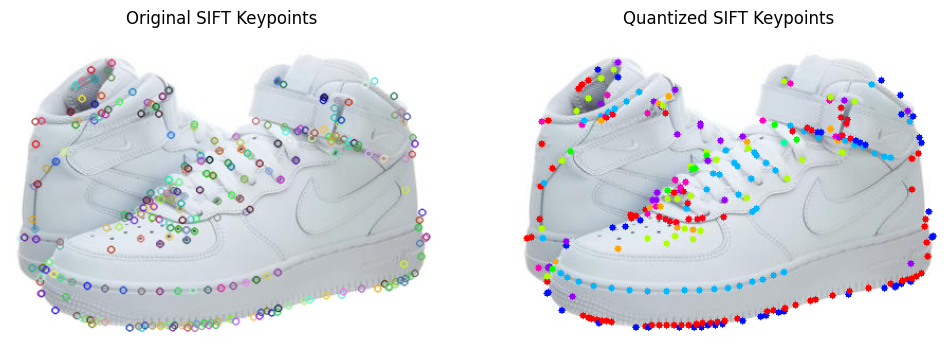

In [41]:
query_idx = 155
similar_images, dissimilar_images = retrieve_images(query_idx, image_histograms)
#생성된 SIFT VECTOR의 keypoints 확인
query_img_with_keypoints = extract_and_draw_keypoints(dataset[query_idx]['image'])
colored_keypoints_image = extract_and_draw_keypoints_quantized(np.array(dataset[query_idx]['image']), kmeans)
plt.figure(figsize=(12, 6))

# Original keypoints
plt.subplot(1, 2, 1)

plt.imshow(query_img_with_keypoints)
plt.title('Original SIFT Keypoints')
plt.axis('off')

# Quantized keypoints
plt.subplot(1, 2, 2)

plt.imshow(colored_keypoints_image)
plt.title('Quantized SIFT Keypoints')
plt.axis('off')

plt.show()

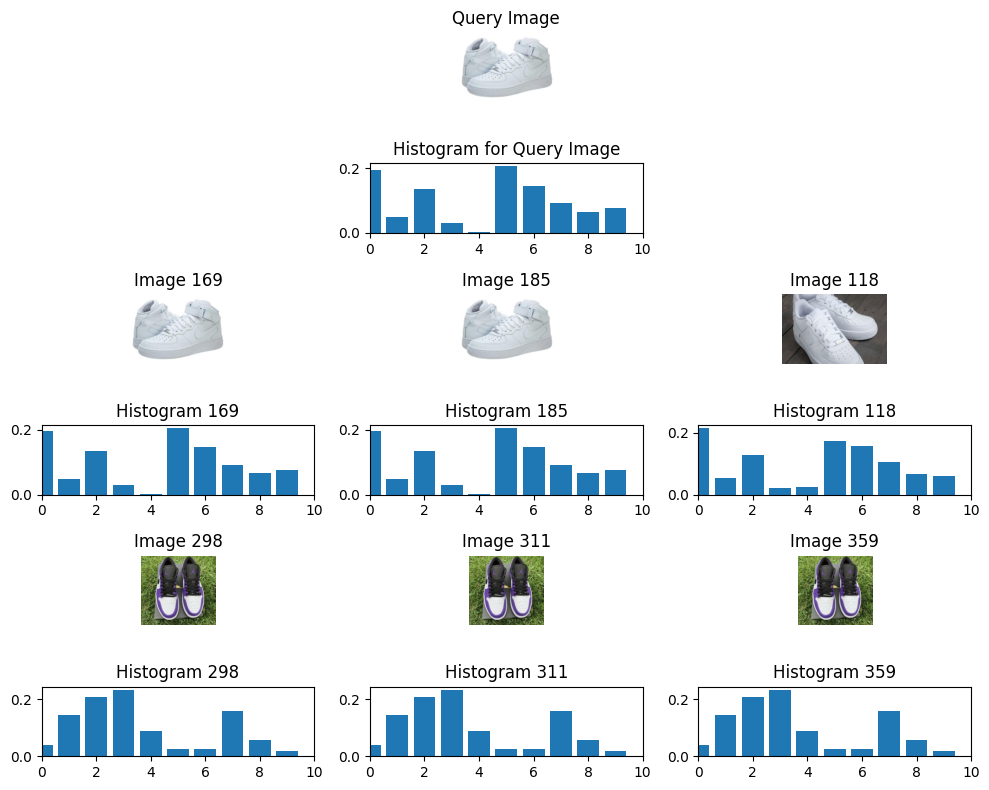

In [ ]:
plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(6, 3)

plt.subplot(gs[0, :])
plt.imshow(dataset[query_idx]['image'])
plt.title('Query Image')
plt.axis('off')

plt.subplot(gs[1, 1])
plt.bar(range(num_clusters), image_histograms[query_idx])
plt.title('Histogram for Query Image')
plt.xlim([0, num_clusters])

display_row_of_images_and_histograms(similar_images, 2, gs, num_clusters)

display_row_of_images_and_histograms(dissimilar_images, 4, gs, num_clusters)

plt.tight_layout()
plt.show()

<font color=yellow>

## 여기까지가 딥러닝 발전 이전에 자주 쓰이던 기초적인 방식임 
## - histogram 유사도 검색
## - SIFT 유사도 검색 (객체 엣지 특화됨)

## 다음은 
## - CNN 기반 유사도
## - 트랜스포머 기반 검색
## - CLIP 기반 검색
</font>